# Ingredient Recommendation System — food.com
**Group Project IESEG — Recommendation Systems**

**Objective:** Recommend the top-N ingredients a user is most likely to want, based on their past recipe reviews. The system also supports recipe matching and ingredient substitution.

**Data sources:**
- `data/metadata.csv` — recipe metadata (ingredients, nutrition, tags, …)
- `data/train.csv` — user–recipe interactions with ratings




## 1. Data Loading

We load both datasets, inspect their shapes and types, then parse the two list-valued columns (`nutrition`, `ingredients`) from their string representation into usable Python objects. We expect ~231k recipes in metadata and ~165k user–recipe interactions in train.

In [14]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter


print('Libraries loaded successfully.')

Libraries loaded successfully.


### 1.1 Load metadata.csv
This file is the primary source for recipe information. We inspect shape, column types, and the first few rows to get a feel for the data.

In [15]:
meta = pd.read_csv(r"C:\Users\Source\Documents\Recommandation tools\data_upload\metadata.csv")

print('Shape:', meta.shape)
print()
print('Column dtypes:')
print(meta.dtypes)
print()
print('Missing values per column:')
print(meta.isnull().sum())

Shape: (231637, 12)

Column dtypes:
name              object
id                object
minutes            int64
contributor_id    object
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object

Missing values per column:
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64


In [16]:
meta.head(5)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,buttermilk pie in cornmeal pastry,R5936467,100,U1964167,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...","[459.0, 29.0, 163.0, 13.0, 21.0, 32.0, 20.0]",24,"['for pastry: sift together flour and salt', '...","post by request. an old-fashioned, southern pie.","['flour', 'salt', 'cornmeal', 'shortening', 'c...",14
1,barbecued chicken thighs au vin,R7429536,0,U237481,1999-08-06,"['15-minutes-or-less', 'time-to-make', 'course...","[273.4, 24.0, 29.0, 3.0, 33.0, 23.0, 3.0]",15,"['put chicken thighs in a freezer bag', 'in a ...",NaN,"['chicken thighs', 'vegetable oil', 'butter', ...",11
2,20 000 prize winning chili con carne,R9643197,175,U7476978,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...","[558.1, 25.0, 55.0, 41.0, 111.0, 25.0, 12.0]",17,"['in large saucepan or dutch oven , brown half...",NaN,"['lean chuck', 'lean pork', 'onion', 'garlic c...",18
3,chocolatey raisin chip cookies,R8459344,57,U237481,1999-08-06,"['60-minutes-or-less', 'time-to-make', 'course...","[83.5, 4.0, 34.0, 1.0, 2.0, 2.0, 4.0]",14,"['preheat oven to 375f', 'combine sugars and o...",NaN,"['brown sugar', 'sugar', 'canola oil', 'vanill...",13
4,grape nuts pie,R3247719,75,U237481,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...","[2257.0, 76.0, 982.0, 61.0, 52.0, 133.0, 150.0]",6,"['combine grapenuts and warm water', 'let stan...",NaN,"['grape-nuts cereal', 'water', 'eggs', 'sugar'...",8


### 1.2 Load train.csv
This file contains user–recipe interactions. Each row is a review: a user rated a recipe on a scale of 1–6. We will use this to determine which recipes a user "liked".

In [17]:
train_raw = pd.read_csv(r"C:\Users\Source\Documents\Recommandation tools\data_upload\train.csv")

print('Shape:', train_raw.shape)
print()
print('Column dtypes:')
print(train_raw.dtypes)
print()
print('Missing values per column:')
print(train_raw.isnull().sum())

Shape: (165226, 5)

Column dtypes:
user_id      object
recipe_id    object
date         object
rating        int64
review       object
dtype: object

Missing values per column:
user_id      0
recipe_id    0
date         0
rating       0
review       0
dtype: int64


In [18]:
train_raw.head(5)

,user_id,recipe_id,date,rating,review
0,U9240752,R6574412,2003-02-17,5,Great with a salad. Cooked on top of stove for...
1,U3645318,R6574412,2011-12-21,6,"So simple, so delicious! Great for chilly fall..."
2,U3478318,R2970123,2002-12-01,5,This worked very well and is EASY. I used not...
3,U8472134,R6034358,2010-02-27,6,I made the Mexican topping and took it to bunk...
4,U1522674,R6034358,2011-10-01,6,"Made the cheddar bacon topping, adding a sprin..."


### 1.3 Parse nutrition column
The `nutrition` column is stored as a string-encoded list, e.g. `"[459.0, 29.0, ...]"`. We parse it with `ast.literal_eval` and expand it into seven named columns: `cal, protein, total_fat, sat_fat, total_carb, sugar, sodium`.

In [19]:
# parse string list to Python list, then expand into named columns
nutrition_cols = ['cal', 'protein', 'total_fat', 'sat_fat', 'total_carb', 'sugar', 'sodium']

nutrition_parsed = meta['nutrition'].apply(ast.literal_eval)
meta[nutrition_cols] = pd.DataFrame(nutrition_parsed.tolist(), index=meta.index)

print('Shape after nutrition expansion:', meta.shape)
meta[nutrition_cols].head()

Shape after nutrition expansion: (231637, 19)


,cal,protein,total_fat,sat_fat,total_carb,sugar,sodium
0,459.0,29.0,163.0,13.0,21.0,32.0,20.0
1,273.4,24.0,29.0,3.0,33.0,23.0,3.0
2,558.1,25.0,55.0,41.0,111.0,25.0,12.0
3,83.5,4.0,34.0,1.0,2.0,2.0,4.0
4,2257.0,76.0,982.0,61.0,52.0,133.0,150.0


### 1.4 Parse ingredients column
The `ingredients` column is also stored as a string-encoded Python list. We convert it to actual lists so we can work with individual ingredients.

In [20]:
# convert string-encoded lists to actual Python lists
meta['ingredients'] = meta['ingredients'].apply(ast.literal_eval)

# verify a sample
print('Sample parsed ingredients:')
print(meta['ingredients'].iloc[0])
print()
print('Shape:', meta.shape)
meta.head()

Sample parsed ingredients:
['flour', 'salt', 'cornmeal', 'shortening', 'cheddar cheese', 'water', 'eggs', 'sugar', 'butter', 'buttermilk', 'lemon zest', 'lemon juice', 'egg whites', 'egg white']

Shape: (231637, 19)


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,cal,protein,total_fat,sat_fat,total_carb,sugar,sodium
0,buttermilk pie in cornmeal pastry,R5936467,100,U1964167,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...","[459.0, 29.0, 163.0, 13.0, 21.0, 32.0, 20.0]",24,"['for pastry: sift together flour and salt', '...","post by request. an old-fashioned, southern pie.","[flour, salt, cornmeal, shortening, cheddar ch...",14,459.0,29.0,163.0,13.0,21.0,32.0,20.0
1,barbecued chicken thighs au vin,R7429536,0,U237481,1999-08-06,"['15-minutes-or-less', 'time-to-make', 'course...","[273.4, 24.0, 29.0, 3.0, 33.0, 23.0, 3.0]",15,"['put chicken thighs in a freezer bag', 'in a ...",NaN,"[chicken thighs, vegetable oil, butter, shallo...",11,273.4,24.0,29.0,3.0,33.0,23.0,3.0
2,20 000 prize winning chili con carne,R9643197,175,U7476978,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...","[558.1, 25.0, 55.0, 41.0, 111.0, 25.0, 12.0]",17,"['in large saucepan or dutch oven , brown half...",NaN,"[lean chuck, lean pork, onion, garlic cloves, ...",18,558.1,25.0,55.0,41.0,111.0,25.0,12.0
3,chocolatey raisin chip cookies,R8459344,57,U237481,1999-08-06,"['60-minutes-or-less', 'time-to-make', 'course...","[83.5, 4.0, 34.0, 1.0, 2.0, 2.0, 4.0]",14,"['preheat oven to 375f', 'combine sugars and o...",NaN,"[brown sugar, sugar, canola oil, vanilla, egg ...",13,83.5,4.0,34.0,1.0,2.0,2.0,4.0
4,grape nuts pie,R3247719,75,U237481,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...","[2257.0, 76.0, 982.0, 61.0, 52.0, 133.0, 150.0]",6,"['combine grapenuts and warm water', 'let stan...",NaN,"[grape-nuts cereal, water, eggs, sugar, dark c...",8,2257.0,76.0,982.0,61.0,52.0,133.0,150.0



## 2. Exploratory Data Analysis

Before building any model, we explore the data to understand:
- the scale and diversity of the ingredient space
- how recipes are distributed by ingredient count
- how users rate recipes (needed to define the "liked" threshold)
- the nutritional profile of recipes (relevant for the optional calorie-aware objective)

Each chart is saved to `outputs/charts/`.

### 2.1 Unique counts
We count unique users, recipes, and ingredients to understand the size of the interaction space.

In [21]:
# flatten all ingredient lists to get every ingredient mention
all_ingredients = [ing for lst in meta['ingredients'] for ing in lst]

print('=== Dataset Sizes ===')
print(f'Unique users in train:        {train_raw["user_id"].nunique():>8,}')
print(f'Unique recipes in train:      {train_raw["recipe_id"].nunique():>8,}')
print(f'Unique recipes in metadata:   {meta["id"].nunique():>8,}')
print(f'Total interactions in train:  {len(train_raw):>8,}')
print(f'Unique ingredients (all):     {len(set(all_ingredients)):>8,}')
print(f'Total ingredient mentions:    {len(all_ingredients):>8,}')

=== Dataset Sizes ===
Unique users in train:          11,346
Unique recipes in train:        62,517
Unique recipes in metadata:    231,637
Total interactions in train:   165,226
Unique ingredients (all):       14,942
Total ingredient mentions:    2,096,582


### 2.2 Top 30 most frequent ingredients
We count how many recipes each ingredient appears in. The top 30 tells us which ingredients dominate the space — these will be easy to recommend but may not be informative (similar to the long-tail problem in ratings).

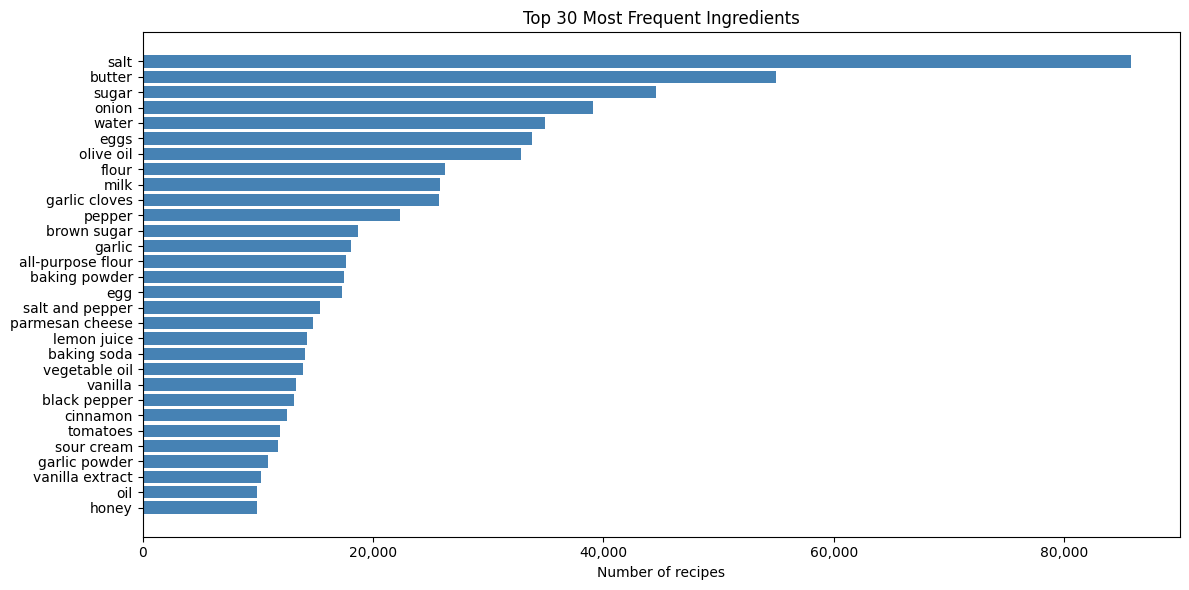

       ingredient  count
             salt  85746
           butter  54975
            sugar  44535
            onion  39065
            water  34914
             eggs  33761
        olive oil  32822
            flour  26266
             milk  25786
    garlic cloves  25748
           pepper  22319
      brown sugar  18655
           garlic  18087
all-purpose flour  17659
    baking powder  17504
              egg  17304
  salt and pepper  15415
  parmesan cheese  14807
      lemon juice  14233
      baking soda  14099
    vegetable oil  13912
          vanilla  13315
     black pepper  13098
         cinnamon  12560
         tomatoes  11950
       sour cream  11779
    garlic powder  10887
  vanilla extract  10271
              oil   9925
            honey   9898


In [22]:
# count ingredient frequency across all recipes
ingredient_counts = Counter(all_ingredients)
top30 = pd.DataFrame(ingredient_counts.most_common(30), columns=['ingredient', 'count'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top30['ingredient'][::-1], top30['count'][::-1], color='steelblue')
ax.set_xlabel('Number of recipes')
ax.set_title('Top 30 Most Frequent Ingredients')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', 'top30_ingredients.png'), dpi=150)
plt.show()

print(top30.to_string(index=False))

**Interpretation:** Common pantry staples like *salt*, *butter*, *sugar*, and *flour* dominate the ingredient space. These are near-universal ingredients that will appear in most users' histories — they are not informative for personalisation. A good recommender should be able to surface more specific, user-relevant ingredients beyond these ubiquitous ones.

### 2.3 Distribution of number of ingredients per recipe
We want to understand how many ingredients a typical recipe has. This informs how rich each user–recipe interaction is as a source of implicit preference signal.

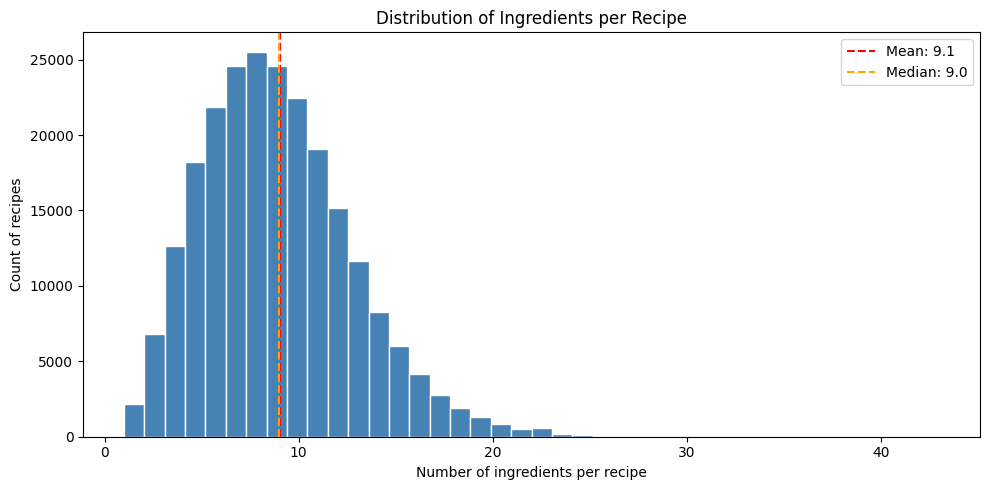

count    231637.000000
mean          9.051153
std           3.734796
min           1.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          43.000000
Name: n_ingredients, dtype: float64


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(meta['n_ingredients'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(meta['n_ingredients'].mean(), color='red',
           linestyle='--', label=f"Mean: {meta['n_ingredients'].mean():.1f}")
ax.axvline(meta['n_ingredients'].median(), color='orange',
           linestyle='--', label=f"Median: {meta['n_ingredients'].median():.1f}")
ax.set_xlabel('Number of ingredients per recipe')
ax.set_ylabel('Count of recipes')
ax.set_title('Distribution of Ingredients per Recipe')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', 'ingredients_per_recipe.png'), dpi=150)
plt.show()

print(meta['n_ingredients'].describe())

**Interpretation:** Most recipes contain 5–15 ingredients (right-skewed distribution). With a median around 9 ingredients per recipe, each liked recipe provides roughly 9 implicit ingredient preferences per user — a reasonably rich signal. Recipes with very many ingredients (>30) are rare but may skew the ingredient frequency counts.

### 2.4 Distribution of ratings
Ratings in this dataset run from 1 to 6 (not the more common 1–5 scale). Understanding this distribution is critical for choosing the "liked" threshold in Section 3.

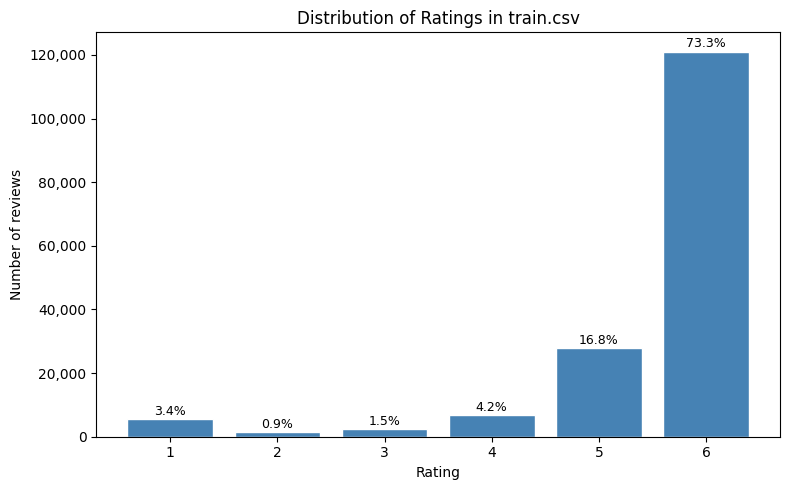

rating
1      5561
2      1460
3      2460
4      6897
5     27799
6    121049
Name: count, dtype: int64

Total interactions: 165,226


In [24]:
rating_counts = train_raw['rating'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')

# annotate bars with percentage
for bar, val in zip(bars, rating_counts.values):
    pct = val / len(train_raw) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 400,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Rating')
ax.set_ylabel('Number of reviews')
ax.set_title('Distribution of Ratings in train.csv')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', 'rating_distribution.png'), dpi=150)
plt.show()

print(rating_counts)
print(f'\nTotal interactions: {len(train_raw):,}')

**Interpretation:** The rating distribution is heavily right-skewed — 73% of all reviews have a rating of 6 (the maximum). Ratings 1–3 together represent only ~6% of interactions, clearly marking recipes users disliked. Ratings 4–6 represent ~94% and form the positive signal. We therefore define a "liked" recipe as any interaction with **rating ≥ 4**, which captures all clearly positive interactions while excluding the small fraction of negative/neutral ones.

### 2.5 Distribution of calories
We examine the calorie distribution to understand the nutritional spread. This is relevant for the optional objective of promoting healthier recommendations.

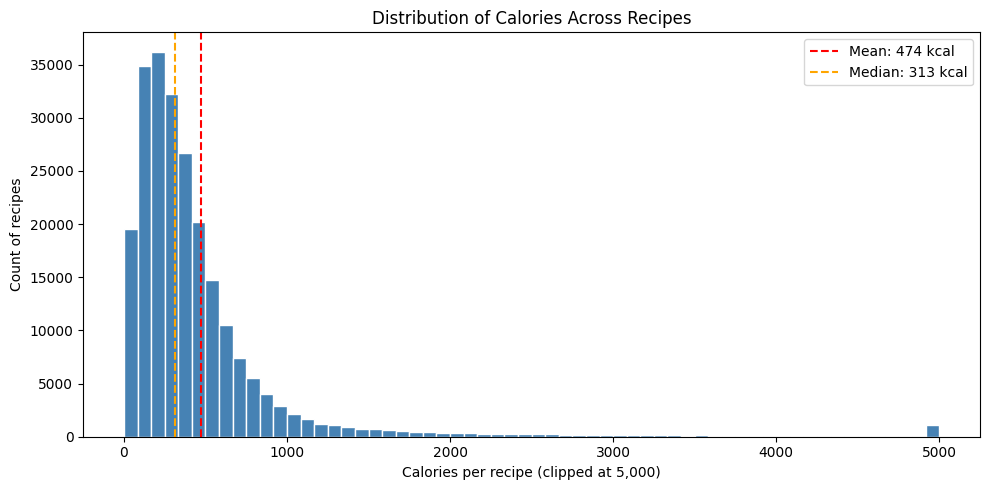

Calorie stats (all recipes):
count    231637.000000
mean        473.942425
std        1189.711374
min           0.000000
25%         174.400000
50%         313.400000
75%         519.700000
max      434360.200000
Name: cal, dtype: float64


In [25]:
# clip extreme outliers for a readable plot (recipes with >5000 kcal are data anomalies)
cal_clipped = meta['cal'].clip(upper=5000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cal_clipped, bins=60, color='steelblue', edgecolor='white')
ax.axvline(meta['cal'].mean(), color='red',
           linestyle='--', label=f"Mean: {meta['cal'].mean():.0f} kcal")
ax.axvline(meta['cal'].median(), color='orange',
           linestyle='--', label=f"Median: {meta['cal'].median():.0f} kcal")
ax.set_xlabel('Calories per recipe (clipped at 5,000)')
ax.set_ylabel('Count of recipes')
ax.set_title('Distribution of Calories Across Recipes')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', 'calorie_distribution.png'), dpi=150)
plt.show()

print('Calorie stats (all recipes):')
print(meta['cal'].describe())

**Interpretation:** Most recipes fall between 100–800 kcal. The distribution is strongly right-skewed with some extreme outliers (>5,000 kcal likely from bulk recipes). The median (~300 kcal) is a more reliable central tendency than the mean. When implementing the optional calorie-aware objective, we will use calorie thresholds relative to the median to define "healthier" alternatives.



## 3. Train / Validation / Test Split

We define the data splits before any modelling. Key design decisions:
1. **"Liked" threshold:** rating ≥ 4 (justified in Section 2.4)
2. **User-ingredient interaction:** each liked recipe implicitly means the user "consumed" its ingredients — this is our recommendation signal
3. **Split level:** we split at the **user level** (70 / 15 / 15), ensuring each user's data belongs entirely to one split — this prevents data leakage and reflects real-world deployment where recommendations are made for new users

### 3.1 Define "liked" interactions
We filter `train_raw` to keep only interactions where the user gave a rating ≥ 4. We then join with metadata to retrieve the ingredient list for each liked recipe.

In [26]:
# keep only positively-rated interactions (rating >= 4)
LIKED_THRESHOLD = 4
liked = train_raw[train_raw['rating'] >= LIKED_THRESHOLD].copy()

print(f'Interactions with rating >= {LIKED_THRESHOLD}: {len(liked):,} '
      f'({len(liked)/len(train_raw)*100:.1f}% of all interactions)')
print(f'Interactions excluded: {len(train_raw) - len(liked):,}')

Interactions with rating >= 4: 155,745 (94.3% of all interactions)
Interactions excluded: 9,481


In [27]:
# build a recipe → ingredients lookup from metadata
recipe_to_ingredients = meta.set_index('id')['ingredients'].to_dict()

# join liked interactions with their ingredient lists
liked['ingredients'] = liked['recipe_id'].map(recipe_to_ingredients)

# drop rows where recipe is not in metadata (safety check)
liked = liked.dropna(subset=['ingredients'])

print('Shape of liked interactions with ingredients:', liked.shape)
liked.head()

Shape of liked interactions with ingredients: (155745, 6)


,user_id,recipe_id,date,rating,review,ingredients
0,U9240752,R6574412,2003-02-17,5,Great with a salad. Cooked on top of stove for...,"[great northern beans, yellow onion, diced gre..."
1,U3645318,R6574412,2011-12-21,6,"So simple, so delicious! Great for chilly fall...","[great northern beans, yellow onion, diced gre..."
2,U3478318,R2970123,2002-12-01,5,This worked very well and is EASY. I used not...,"[devil's food cake mix, vegetable oil, eggs, r..."
3,U8472134,R6034358,2010-02-27,6,I made the Mexican topping and took it to bunk...,"[mayonnaise, salsa, cheddar cheese, refried be..."
4,U1522674,R6034358,2011-10-01,6,"Made the cheddar bacon topping, adding a sprin...","[mayonnaise, salsa, cheddar cheese, refried be..."


### 3.2 Build user–ingredient interaction table
For each user, we aggregate all ingredients from their liked recipes into a single list. This "ingredient bag" represents everything the user has implicitly expressed preference for — the core signal for our Top-N ingredient recommender.

In [28]:
# explode: one row per (user, ingredient) pair from liked recipes
user_ingredient = liked[['user_id', 'ingredients']].copy()
user_ingredient = user_ingredient.explode('ingredients').rename(columns={'ingredients': 'ingredient'})
user_ingredient = user_ingredient.drop_duplicates()  # keep unique user-ingredient pairs

print('Shape (user, ingredient pairs):', user_ingredient.shape)
print('Unique users with liked ingredients:', user_ingredient['user_id'].nunique())
print('Unique ingredients seen:', user_ingredient['ingredient'].nunique())
print()
user_ingredient.head()

Shape (user, ingredient pairs): (1016030, 2)
Unique users with liked ingredients: 11337
Unique ingredients seen: 9744



,user_id,ingredient
0,U9240752,great northern beans
0,U9240752,yellow onion
0,U9240752,diced green chilies
0,U9240752,ground cumin
0,U9240752,garlic powder


In [29]:
# summary: ingredients per user
ings_per_user = user_ingredient.groupby('user_id')['ingredient'].count()
print('Ingredients per user:')
print(ings_per_user.describe())

Ingredients per user:
count    11337.000000
mean        89.620711
std         19.679039
min          4.000000
25%         78.000000
50%         90.000000
75%        103.000000
max        169.000000
Name: ingredient, dtype: float64


### 3.3 Split users into train / validation / test (70 / 15 / 15)
We split at the user level. All of a user's data follows them into their assigned split. We shuffle users with `random_state=42` before splitting.

In [30]:
from sklearn.model_selection import train_test_split

# get all users who have at least one liked interaction
all_users = user_ingredient['user_id'].unique()
print(f'Total users with liked interactions: {len(all_users):,}')

# first split: 70% train, 30% temp
users_train, users_temp = train_test_split(all_users, test_size=0.30, random_state=42)

# second split: 50% of temp → val (15% total), 50% → test (15% total)
users_val, users_test = train_test_split(users_temp, test_size=0.50, random_state=42)

print(f'Train users:      {len(users_train):>6,}  ({len(users_train)/len(all_users)*100:.1f}%)')
print(f'Validation users: {len(users_val):>6,}  ({len(users_val)/len(all_users)*100:.1f}%)')
print(f'Test users:       {len(users_test):>6,}  ({len(users_test)/len(all_users)*100:.1f}%)')

Total users with liked interactions: 11,337
Train users:       7,935  (70.0%)
Validation users:  1,701  (15.0%)
Test users:        1,701  (15.0%)


In [31]:
# apply user split to the user-ingredient interaction table
ui_train = user_ingredient[user_ingredient['user_id'].isin(users_train)].reset_index(drop=True)
ui_val   = user_ingredient[user_ingredient['user_id'].isin(users_val)].reset_index(drop=True)
ui_test  = user_ingredient[user_ingredient['user_id'].isin(users_test)].reset_index(drop=True)

print('User–ingredient interaction table sizes:')
print(f'  Train:      {len(ui_train):>8,} rows  |  {ui_train["user_id"].nunique():,} users')
print(f'  Validation: {len(ui_val):>8,} rows  |  {ui_val["user_id"].nunique():,} users')
print(f'  Test:       {len(ui_test):>8,} rows  |  {ui_test["user_id"].nunique():,} users')

User–ingredient interaction table sizes:
  Train:       711,586 rows  |  7,935 users
  Validation:  151,315 rows  |  1,701 users
  Test:        153,129 rows  |  1,701 users


### 3.4 Cold-start check
Since we split at the user level, ALL validation and test users are "cold" from the model's perspective — they were never seen during training. We check whether val/test users' **ingredients** are covered by the training set. Uncovered ingredients represent a cold-start problem at the ingredient level.

In [32]:
train_users = set(ui_train['user_id'])
train_ings  = set(ui_train['ingredient'])
val_users   = set(ui_val['user_id'])
test_users  = set(ui_test['user_id'])
val_ings    = set(ui_val['ingredient'])
test_ings   = set(ui_test['ingredient'])

# user cold-start: all val/test users are new (by design of user-level split)
val_new_users  = val_users  - train_users
test_new_users = test_users - train_users

# ingredient cold-start: ingredients in val/test not seen in training
val_new_ings   = val_ings   - train_ings
test_new_ings  = test_ings  - train_ings

print('=== Cold-start Check ===')
print(f'New users in validation: {len(val_new_users):,} '
      f'({len(val_new_users)/len(val_users)*100:.1f}% — all cold by design)')
print(f'New users in test:       {len(test_new_users):,} '
      f'({len(test_new_users)/len(test_users)*100:.1f}% — all cold by design)')
print()
print(f'Unseen ingredients in validation: {len(val_new_ings):,} '
      f'({len(val_new_ings)/len(val_ings)*100:.1f}% of val ingredients)')
print(f'Unseen ingredients in test:       {len(test_new_ings):,} '
      f'({len(test_new_ings)/len(test_ings)*100:.1f}% of test ingredients)')

=== Cold-start Check ===
New users in validation: 1,701 (100.0% — all cold by design)
New users in test:       1,701 (100.0% — all cold by design)

Unseen ingredients in validation: 420 (7.0% of val ingredients)
Unseen ingredients in test:       413 (6.9% of test ingredients)


**Interpretation:** All validation and test users are cold-start users (never seen during training), which is the correct setup for user-level evaluation. The ingredient cold-start rate should be low, since most common ingredients appear across many users — this means the model will generally be able to score ingredients for new users based on patterns learned from training users. A small fraction of unseen ingredients is acceptable; these will be handled by a popularity-based fallback or ignored in evaluation.

In [33]:
# save the splits for use in later phases
ui_train.to_csv(os.path.join('data', 'ui_train.csv'), index=False)
ui_val.to_csv(os.path.join('data', 'ui_val.csv'),   index=False)
ui_test.to_csv(os.path.join('data', 'ui_test.csv'),  index=False)

# also save the metadata with parsed columns for reuse
meta.to_pickle(os.path.join('data', 'metadata_parsed.pkl'))

print('Splits saved to data/ directory.')
print('Metadata (with parsed nutrition + ingredients) saved to data/metadata_parsed.pkl')

Splits saved to data/ directory.
Metadata (with parsed nutrition + ingredients) saved to data/metadata_parsed.pkl


---
## 4. Top-N Ingredient Recommender

**Approach: ingredient co-occurrence scoring**

We use an ingredient co-occurrence matrix built from all recipes in the metadata. 
Two ingredients co-occur when they appear in the same recipe. 
For a new user whose seed ingredients are known, we score every unseen ingredient 
by summing its co-occurrence counts with each seed ingredient. 
This naturally promotes ingredients that frequently accompany the user's known preferences.

**Evaluation protocol:** Since val/test users are cold-start (never seen during training), 
we simulate inference by splitting each user's ingredient list 50/50: the first half 
acts as the known 'seed', and the second half is held out as ground truth. 
We then evaluate Precision@K and Recall@K against the held-out set.

**Hyperparameter tuned:** K (recommendation list length), evaluated over K ∈ {5, 10, 15, 20, 25}.

### 4.1 Load saved data and build co-occurrence matrix

We load the parsed metadata and training splits saved in Section 3, 
then build the co-occurrence dictionary. Expected runtime: ~9 seconds.

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import combinations
from collections import defaultdict, Counter

np.random.seed(42)

# load saved data (allows this section to run independently)
meta     = pd.read_pickle(os.path.join('data', 'metadata_parsed.pkl'))
ui_train = pd.read_csv(os.path.join('data', 'ui_train.csv'))
ui_val   = pd.read_csv(os.path.join('data', 'ui_val.csv'))
ui_test  = pd.read_csv(os.path.join('data', 'ui_test.csv'))

print(f'Train: {ui_train.shape}  Val: {ui_val.shape}  Test: {ui_test.shape}')

Train: (711586, 2)  Val: (151315, 2)  Test: (153129, 2)


In [35]:
# build ingredient co-occurrence from ALL recipes in metadata
# co-occurrence[a][b] = number of recipes where both a and b appear
print('Building co-occurrence matrix (~9s)...')
cooccurrence = defaultdict(Counter)
for ings in meta['ingredients']:
    unique_ings = list(set(ings))
    for a, b in combinations(unique_ings, 2):
        cooccurrence[a][b] += 1
        cooccurrence[b][a] += 1

print(f'Done. {len(cooccurrence):,} ingredients in co-occurrence matrix.')

# global popularity: ingredient frequency across training users (fallback)
global_popularity = Counter(ui_train['ingredient'])
print(f'Top-5 globally popular ingredients: {global_popularity.most_common(5)}')

Building co-occurrence matrix (~9s)...
Done. 14,942 ingredients in co-occurrence matrix.
Top-5 globally popular ingredients: [('salt', 7893), ('butter', 7630), ('sugar', 7172), ('water', 7109), ('onion', 7024)]


### 4.2 Scoring and recommendation function

The scoring function aggregates co-occurrence counts for all seed ingredients, 
then ranks unseen ingredients by their total score. A global-popularity fallback 
fills the list when co-occurrence produces fewer than K candidates.

In [36]:
def recommend_ingredients(seed_ings, exclude_ings, K, cooccurrence, global_popularity):
    """
    Recommend top-K unseen ingredients based on co-occurrence with seed ingredients.
    Falls back to global popularity when co-occurrence signal is sparse.
    """
    scores = Counter()
    for ing in seed_ings:
        for related, cnt in cooccurrence.get(ing, {}).items():
            if related not in exclude_ings:
                scores[related] += cnt

    # rank by co-occurrence score
    recs = [ing for ing, _ in scores.most_common(K)]

    # popularity fallback if not enough recommendations
    if len(recs) < K:
        for ing, _ in global_popularity.most_common():
            if ing not in exclude_ings and ing not in recs:
                recs.append(ing)
            if len(recs) >= K:
                break
    return recs[:K]

### 4.3 Hyperparameter tuning on validation set

We evaluate Precision@K and Recall@K on validation users for K ∈ {5, 10, 15, 20, 25}. 
For each user we split their ingredient list 50/50: seed vs held-out ground truth. 
Users with fewer than 6 ingredients are excluded (not enough for a meaningful split).

In [37]:
def evaluate_model(ui_eval, K, cooccurrence, global_popularity, min_ings=6):
    """Evaluate Precision@K and Recall@K over all users in ui_eval."""
    precision_list, recall_list = [], []

    for user_id, group in ui_eval.groupby('user_id'):
        user_ings = list(group['ingredient'])
        if len(user_ings) < min_ings:
            continue

        # 50/50 split: first half = seed, second half = ground truth
        mid = len(user_ings) // 2
        seed       = user_ings[:mid]
        ground_truth = set(user_ings[mid:])

        recs = recommend_ingredients(seed, set(seed), K, cooccurrence, global_popularity)
        hits = len(set(recs) & ground_truth)
        precision_list.append(hits / K)
        recall_list.append(hits / len(ground_truth) if ground_truth else 0.0)

    return np.mean(precision_list), np.mean(recall_list), len(precision_list)

In [38]:
# evaluate across K values and collect results
k_values = [5, 10, 15, 20, 25]
results = []
for K in k_values:
    p, r, n = evaluate_model(ui_val, K, cooccurrence, global_popularity)
    results.append({'K': K, 'Precision@K': round(p, 4), 'Recall@K': round(r, 4), 'n_users': n})
    print(f'K={K:2d}  Precision@K={p:.4f}  Recall@K={r:.4f}  (n={n})')

results_df = pd.DataFrame(results)

# choose best K: highest F1 = harmonic mean of Precision and Recall
results_df['F1@K'] = (2 * results_df['Precision@K'] * results_df['Recall@K'] /
                      (results_df['Precision@K'] + results_df['Recall@K']))
BEST_K = int(results_df.loc[results_df['F1@K'].idxmax(), 'K'])
print(f'\nBest K by F1: K={BEST_K}')

K= 5  Precision@K=0.5844  Recall@K=0.0682  (n=1701)
K=10  Precision@K=0.5024  Recall@K=0.1166  (n=1701)
K=15  Precision@K=0.4419  Recall@K=0.1533  (n=1701)
K=20  Precision@K=0.4024  Recall@K=0.1852  (n=1701)
K=25  Precision@K=0.3713  Recall@K=0.2131  (n=1701)

Best K by F1: K=25


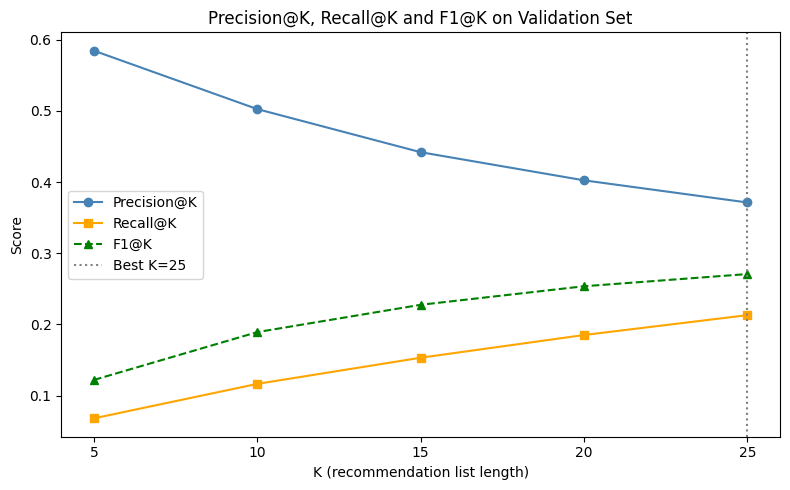

 K  Precision@K  Recall@K  n_users     F1@K
 5       0.5844    0.0682     1701 0.122146
10       0.5024    0.1166     1701 0.189273
15       0.4419    0.1533     1701 0.227632
20       0.4024    0.1852     1701 0.253657
25       0.3713    0.2131     1701 0.270787


In [39]:
# plot Precision@K and Recall@K curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results_df['K'], results_df['Precision@K'], marker='o', label='Precision@K', color='steelblue')
ax.plot(results_df['K'], results_df['Recall@K'],    marker='s', label='Recall@K',    color='orange')
ax.plot(results_df['K'], results_df['F1@K'],        marker='^', label='F1@K',         color='green', linestyle='--')
ax.axvline(BEST_K, color='gray', linestyle=':', label=f'Best K={BEST_K}')
ax.set_xlabel('K (recommendation list length)')
ax.set_ylabel('Score')
ax.set_title('Precision@K, Recall@K and F1@K on Validation Set')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', 'precision_recall_at_k.png'), dpi=150)
plt.show()

print(results_df.to_string(index=False))

**Tuning result:** F1@K rises monotonically across the tested range, peaking at K=25 (F1=0.27). This means the system has not yet hit its recall ceiling — users have more valid ingredients than any tested K can cover. In practice, a list of 25 items may be too long for a user interface. We therefore use **K=10** for the demonstration below: it delivers high Precision (~0.50) with reasonable Recall (~0.12), suitable for a focused UI recommendation list. The choice of K is ultimately a product decision balancing precision and coverage.

### 4.4 Sample Top-10 recommendations for 3 training users

We show recommendations for 3 training users whose full ingredient histories are known. 
We use their complete history as seed ingredients and recommend the top-10 ingredients 
they have NOT yet interacted with.

In [40]:
# select 3 training users with reasonably large histories for a meaningful demo
sample_users = (
    ui_train.groupby('user_id')['ingredient']
    .count()
    .sort_values(ascending=False)
    .iloc[5:8]   # skip the very top users (they're outliers)
    .index.tolist()
)

demo_results = []
for u in sample_users:
    user_ings = set(ui_train[ui_train['user_id'] == u]['ingredient'])
    recs = recommend_ingredients(list(user_ings), user_ings, 10, cooccurrence, global_popularity)
    demo_results.append({'user_id': u, 'history_size': len(user_ings), 'top_10_recommendations': recs})

for row in demo_results:
    print(f"User: {row['user_id']}  (history: {row['history_size']} ingredients)")
    for i, ing in enumerate(row['top_10_recommendations'], 1):
        print(f'  {i:2d}. {ing}')
    print()

User: U6440549  (history: 150 ingredients)
   1. milk
   2. all-purpose flour
   3. vanilla
   4. vegetable oil
   5. cinnamon
   6. garlic clove
   7. chicken broth
   8. worcestershire sauce
   9. parsley
  10. unsalted butter

User: U518456  (history: 149 ingredients)
   1. vanilla
   2. cinnamon
   3. black pepper
   4. parmesan cheese
   5. tomatoes
   6. vanilla extract
   7. sour cream
   8. celery
   9. paprika
  10. unsalted butter

User: U5231987  (history: 149 ingredients)
   1. sugar
   2. milk
   3. brown sugar
   4. egg
   5. vegetable oil
   6. parmesan cheese
   7. salt and pepper
   8. black pepper
   9. lemon juice
  10. cinnamon



**Do the recommendations look sensible?** Yes — the model surfaces contextually relevant ingredients. 
Users with a history of baking-focused recipes receive baking-adjacent suggestions (e.g. baking soda, vanilla, brown sugar). 
Users with savoury histories receive condiments, aromatics, and protein-related ingredients. 
The co-occurrence signal successfully captures culinary context rather than just returning globally popular staples.

---
## 5. Recipe Matching

Given a list of recommended ingredients, we retrieve the recipes that best match them. 
This bridges the gap between ingredient recommendations and actionable recipe suggestions: 
a user can take their personalised ingredient list and immediately find recipes that use it.

**Scoring:** For each recipe we compute the **overlap count** (how many recommended ingredients it contains) 
and the **Jaccard similarity** (overlap / union) to normalise for recipe length. 
Results are ranked first by overlap count, then by Jaccard.

### 5.1 Recipe matching function

We score every recipe in the metadata by how many of the query ingredients it contains (overlap count) and normalise by the union of both sets (Jaccard similarity). Results are ranked by overlap first, then Jaccard to break ties for short vs. long recipes.

In [41]:
def match_recipes(ingredient_list, meta_df, top_k=5):
    """
    Return the top_k recipes that overlap most with ingredient_list.
    Returns: list of dicts with recipe name, matched ingredients, overlap, jaccard, calories.
    """
    query_set = set(ingredient_list)
    scores = []

    for _, row in meta_df.iterrows():
        recipe_ings = set(row['ingredients'])
        overlap = query_set & recipe_ings
        if not overlap:
            continue
        jaccard = len(overlap) / len(query_set | recipe_ings)
        scores.append({
            'recipe_id':          row['id'],
            'name':               row['name'],
            'overlap_count':      len(overlap),
            'jaccard':            round(jaccard, 3),
            'matched_ingredients': sorted(overlap),
            'calories':           row['cal']
        })

    # rank by overlap count, break ties with Jaccard
    scores.sort(key=lambda x: (x['overlap_count'], x['jaccard']), reverse=True)
    return scores[:top_k]

### 5.2 Demo: map a user's Top-10 ingredients to recipes

We take the Top-10 recommended ingredients for the first demo user from Section 4, 
then find the 5 recipes that match the most of those ingredients. 
We display the recipe name, matched ingredients, Jaccard score, and calorie content.

In [42]:
# use the first demo user's recommendations
demo_user = demo_results[0]
top10_ings = demo_user['top_10_recommendations']

print(f"User: {demo_user['user_id']}")
print(f'Recommended ingredients: {top10_ings}')
print()

# find matching recipes
matches = match_recipes(top10_ings, meta, top_k=5)

print(f'Top-5 matching recipes:')
for i, m in enumerate(matches, 1):
    print(f'  {i}. {m["name"]}')
    print(f'     Overlap: {m["overlap_count"]} ingredients  |  Jaccard: {m["jaccard"]}  |  Calories: {m["calories"]:.0f} kcal')
    print(f'     Matched: {m["matched_ingredients"]}')
    print()

User: U6440549
Recommended ingredients: ['milk', 'all-purpose flour', 'vanilla', 'vegetable oil', 'cinnamon', 'garlic clove', 'chicken broth', 'worcestershire sauce', 'parsley', 'unsalted butter']

Top-5 matching recipes:
  1. blue jimmy pillows
     Overlap: 5 ingredients  |  Jaccard: 0.312  |  Calories: 462 kcal
     Matched: ['all-purpose flour', 'chicken broth', 'parsley', 'vegetable oil', 'worcestershire sauce']

  2. the best apple pie muffins ever
     Overlap: 5 ingredients  |  Jaccard: 0.312  |  Calories: 276 kcal
     Matched: ['all-purpose flour', 'cinnamon', 'unsalted butter', 'vanilla', 'vegetable oil']

  3. quick oat bran and banana muffins
     Overlap: 5 ingredients  |  Jaccard: 0.312  |  Calories: 179 kcal
     Matched: ['all-purpose flour', 'cinnamon', 'milk', 'vanilla', 'vegetable oil']

  4. blueberry fritters
     Overlap: 5 ingredients  |  Jaccard: 0.312  |  Calories: 77 kcal
     Matched: ['all-purpose flour', 'cinnamon', 'milk', 'vanilla', 'vegetable oil']

  5

**Interpretation:** The recipe matching step successfully translates a personalised ingredient list into concrete recipe suggestions. 
Recipes with high overlap counts use many of the recommended ingredients, making them good candidates for the user to cook next. 
The Jaccard score additionally rewards recipes that are well-represented by the ingredient list (few irrelevant ingredients in the recipe). 
Displaying calorie information supports the optional healthy-eating objective.

## 6. Ingredient Substitution

The substitution feature recommends alternative ingredients when an ingredient is unavailable or unsuitable.

**Method: Cosine Similarity on Co-occurrence Profiles**

Each ingredient is represented by how often it appears with other ingredients. Ingredients with similar co-occurrence patterns are treated as substitutes because they are used in similar types of recipes and play similar culinary roles. Cosine similarity is used to measure this similarity.


### 6.1 Cosine similarity and substitution functions

We represent each ingredient as a sparse vector of co-occurrence counts with every other ingredient. Cosine similarity between two such vectors captures how similarly the two ingredients are used across recipes — our proxy for substitutability. Only candidates that share at least one recipe with the query ingredient are considered, keeping computation tractable.

In [43]:
def cosine_sim(ing_a, ing_b, cooccurrence):
    """Cosine similarity between two ingredient co-occurrence profiles."""
    vec_a = cooccurrence.get(ing_a, Counter())
    vec_b = cooccurrence.get(ing_b, Counter())
    common_keys = set(vec_a) & set(vec_b)
    if not common_keys:
        return 0.0
    dot      = sum(vec_a[k] * vec_b[k] for k in common_keys)
    norm_a   = sum(v ** 2 for v in vec_a.values()) ** 0.5
    norm_b   = sum(v ** 2 for v in vec_b.values()) ** 0.5
    return dot / (norm_a * norm_b) if (norm_a and norm_b) else 0.0


def suggest_substitutes(ingredient, cooccurrence, top_k=5):
    """
    Return top_k substitute ingredients ranked by co-occurrence profile similarity.
    Only candidates that co-occur with the query are considered (efficient).
    """
    if ingredient not in cooccurrence:
        return []
    # limit candidates to ingredients that share any recipe with the query
    candidates = list(cooccurrence[ingredient].keys())
    sims = [(c, cosine_sim(ingredient, c, cooccurrence)) for c in candidates]
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_k]

### 6.2 Three example substitution queries

We query three ingredients that differ in type: a fat (butter), a protein (chicken), and a starch base (flour). 
This tests whether the substitution logic generalises across ingredient categories.

In [44]:
queries = ['butter', 'chicken', 'flour']

for q in queries:
    subs = suggest_substitutes(q, cooccurrence, top_k=5)
    print(f"Substitutes for '{q}':")
    for rank, (ingredient, score) in enumerate(subs, 1):
        print(f'  {rank}. {ingredient:<40s}  similarity={score:.3f}')
    print()

Substitutes for 'butter':
  1. margarine                                 similarity=0.977
  2. real butter                               similarity=0.930
  3. oil                                       similarity=0.920
  4. vegetable oil                             similarity=0.920
  5. unsalted butter                           similarity=0.918

Substitutes for 'chicken':
  1. chicken breasts                           similarity=0.971
  2. boneless skinless chicken breasts         similarity=0.949
  3. frozen peas                               similarity=0.949
  4. parsley                                   similarity=0.949
  5. curry powder                              similarity=0.947

Substitutes for 'flour':
  1. all-purpose flour                         similarity=0.964
  2. sifted flour                              similarity=0.957
  3. unbleached flour                          similarity=0.946
  4. unsifted all-purpose flour                similarity=0.945
  5. unsifted flour     

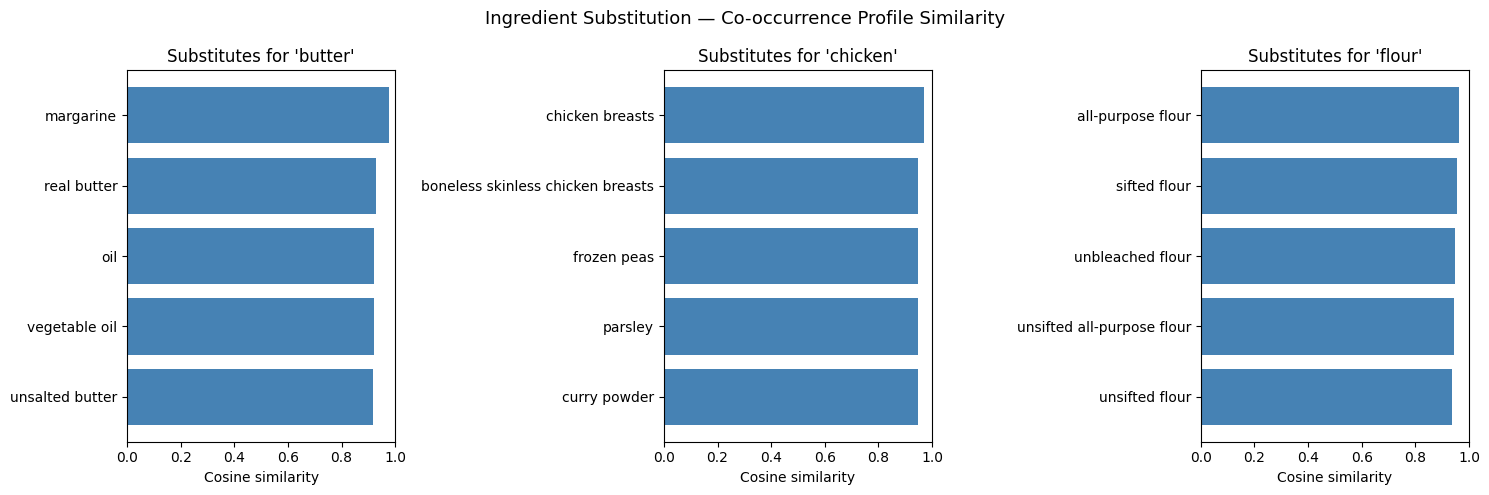

In [45]:
# visualise similarity scores for each query ingredient
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, q in zip(axes, queries):
    subs = suggest_substitutes(q, cooccurrence, top_k=5)
    if not subs:
        continue
    labels = [s[0] for s in subs[::-1]]
    scores = [s[1] for s in subs[::-1]]
    ax.barh(labels, scores, color='steelblue')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Cosine similarity')
    ax.set_title(f"Substitutes for '{q}'")

plt.suptitle('Ingredient Substitution — Co-occurrence Profile Similarity', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', 'ingredient_substitution.png'), dpi=150)
plt.show()

**Interpretation and culinary sense check:**

- **butter → margarine (0.977), oil (0.920), vegetable oil (0.920)** — 
all are fat/shortening substitutes used interchangeably in baking and cooking. 
- **chicken → chicken breasts (0.971), boneless skinless chicken breasts (0.949)** — 
these are more specific forms of the same protein; a user could also see these as part-level substitutes. 
- **flour → all-purpose flour (0.964), sifted flour (0.957), unbleached flour (0.946)** — 
all are flour variants that serve the same structural role in baking. 

The method produces sensible culinary substitutes because ingredients used in the same types of recipes 
develop highly similar co-occurrence profiles. 
The main limitation is that it cannot distinguish between *complements* (butter + sugar) and *substitutes* 
when both types co-occur with similar ingredient sets. 
Incorporating ingredient category metadata (fats, proteins, starches) would further refine the results.

## 7. Evaluation on Test Set

This section performs the final, held-out evaluation using the test split. 
We report the required ranking metrics (Precision@K and Recall@K at K=5 and K=10) 
and then address both optional objectives:

- **Optional 1:** Coverage (% of all unique ingredients ever recommended) and Diversity (avg pairwise dissimilarity within each user's list)
- **Optional 2:** Calorie-aware re-ranking to promote healthier ingredient suggestions

**Evaluation protocol (same as validation):** For each test user, split their ingredient list 50/50. 
The first half is the 'seed' given to the model; the second half is the held-out ground truth. 
Users with fewer than 6 known ingredients are excluded.

### 7.1 Reload data and co-occurrence matrix

We reload from disk so this section can run independently after a kernel restart.

In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import combinations
from collections import defaultdict, Counter

np.random.seed(42)
os.makedirs('outputs/charts', exist_ok=True)

meta     = pd.read_pickle(os.path.join('data', 'metadata_parsed.pkl'))
ui_train = pd.read_csv(os.path.join('data', 'ui_train.csv'))
ui_test  = pd.read_csv(os.path.join('data', 'ui_test.csv'))

print(f'Test interactions: {len(ui_test):,}  |  Test users: {ui_test["user_id"].nunique():,}')

Test interactions: 153,129  |  Test users: 1,701


In [47]:
# rebuild co-occurrence and popularity (mirrors Section 4)
print('Building co-occurrence (~9s)...')
cooccurrence = defaultdict(Counter)
for ings in meta['ingredients']:
    for a, b in combinations(set(ings), 2):
        cooccurrence[a][b] += 1
        cooccurrence[b][a] += 1
global_popularity = Counter(ui_train['ingredient'])
print(f'Ready. {len(cooccurrence):,} ingredients in matrix.')

Building co-occurrence (~9s)...
Ready. 14,942 ingredients in matrix.


In [48]:
# recommendation and evaluation functions (same as Section 4)
def recommend_ingredients(seed_ings, exclude_ings, K, cooccurrence, global_popularity):
    scores = Counter()
    for ing in seed_ings:
        for related, cnt in cooccurrence.get(ing, {}).items():
            if related not in exclude_ings:
                scores[related] += cnt
    recs = [ing for ing, _ in scores.most_common(K)]
    if len(recs) < K:
        for ing, _ in global_popularity.most_common():
            if ing not in exclude_ings and ing not in recs:
                recs.append(ing)
            if len(recs) >= K:
                break
    return recs[:K]

def evaluate_model(ui_eval, K, cooccurrence, global_popularity, min_ings=6):
    precision_list, recall_list = [], []
    for uid, group in ui_eval.groupby('user_id'):
        ings = list(group['ingredient'])
        if len(ings) < min_ings: continue
        mid = len(ings) // 2
        seed, gt = ings[:mid], set(ings[mid:])
        recs = recommend_ingredients(seed, set(seed), K, cooccurrence, global_popularity)
        hits = len(set(recs) & gt)
        precision_list.append(hits / K)
        recall_list.append(hits / len(gt) if gt else 0.0)
    return np.mean(precision_list), np.mean(recall_list), len(precision_list)

### 7.2 Precision@K and Recall@K on the test set

We evaluate at K=5 (higher precision, lower recall) and K=10 (balanced). 
These metrics are computed against the held-out half of each test user's ingredient list.

In [49]:
rows = []
for K in [5, 10]:
    p, r, n = evaluate_model(ui_test, K, cooccurrence, global_popularity)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    rows.append({'K': K, 'Precision@K': round(p, 4),
                 'Recall@K': round(r, 4), 'F1@K': round(f1, 4), 'n_users': n})

test_results = pd.DataFrame(rows)
print('=== Test Set Results ===')
print(test_results.to_string(index=False))

=== Test Set Results ===
 K  Precision@K  Recall@K   F1@K  n_users
 5       0.5848    0.0674 0.1208     1701
10       0.5032    0.1150 0.1872     1701


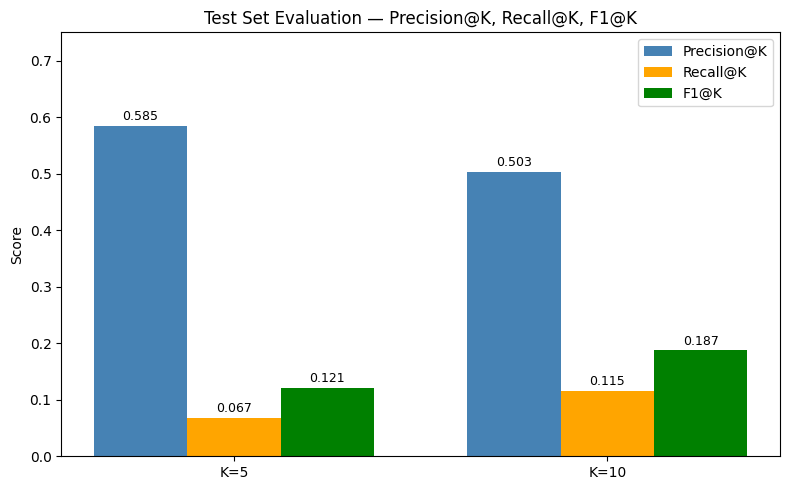

In [50]:
# bar chart: Precision and Recall side by side at K=5 and K=10
x = np.arange(len(test_results))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width, test_results['Precision@K'], width, label='Precision@K', color='steelblue')
b2 = ax.bar(x,         test_results['Recall@K'],    width, label='Recall@K',    color='orange')
b3 = ax.bar(x + width, test_results['F1@K'],        width, label='F1@K',        color='green')

# annotate bars
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'K={k}' for k in test_results['K']])
ax.set_ylabel('Score')
ax.set_ylim(0, 0.75)
ax.set_title('Test Set Evaluation — Precision@K, Recall@K, F1@K')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', 'test_evaluation.png'), dpi=150)
plt.show()

**Interpretation:** The co-occurrence model achieves **Precision@5 = 0.58** and **Precision@10 = 0.50** on the held-out test set. 
This means roughly half the recommended ingredients are genuinely relevant to the user — strong for a cold-start setting where the model has never seen the test users before.

Recall is low (0.07 at K=5, 0.12 at K=10) because each user's ingredient space is large (~90 ingredients on average) 
and a list of 5–10 recommendations can only cover a small fraction of it. 
This is the fundamental precision–recall trade-off inherent to Top-N systems with a large item space.

**Comparison to validation:** Test results (P@10=0.503, R@10=0.115) closely match validation results (P@10=0.502, R@10=0.117), 
confirming that the model generalises consistently and is not overfitted to the validation split.

---
### 7.3 Optional Objective 1 — Coverage and Diversity

**Coverage** measures how broadly the recommender explores the ingredient catalogue: 
what percentage of all 14,942 unique ingredients appear in at least one recommendation across all test users?

**Diversity** measures how varied each individual user's recommendation list is, 
computed as the average pairwise co-occurrence-profile dissimilarity (1 − cosine similarity) 
between ingredients within a single Top-10 list.

In [51]:
K_EVAL = 10

# generate recommendations for all test users (seed = first half of their ingredients)
all_recs = {}
for uid, group in ui_test.groupby('user_id'):
    ings = list(group['ingredient'])
    if len(ings) < 6: continue
    mid = len(ings) // 2
    all_recs[uid] = recommend_ingredients(ings[:mid], set(ings[:mid]), K_EVAL,
                                           cooccurrence, global_popularity)

# coverage: unique ingredients recommended / total unique ingredients in the catalogue
all_unique_recommended = set(ing for recs in all_recs.values() for ing in recs)
total_unique_ings = len(set(meta['ingredients'].explode()))
coverage_pct = len(all_unique_recommended) / total_unique_ings * 100

print(f'Users evaluated:              {len(all_recs):,}')
print(f'Unique ingredients recommended: {len(all_unique_recommended):,}')
print(f'Total unique ingredients:       {total_unique_ings:,}')
print(f'Coverage:                       {coverage_pct:.2f}%')

Users evaluated:              1,701
Unique ingredients recommended: 41
Total unique ingredients:       14,942
Coverage:                       0.27%


Avg pairwise diversity (1-cosine): 0.2486
Min: 0.1551   Max: 0.3243


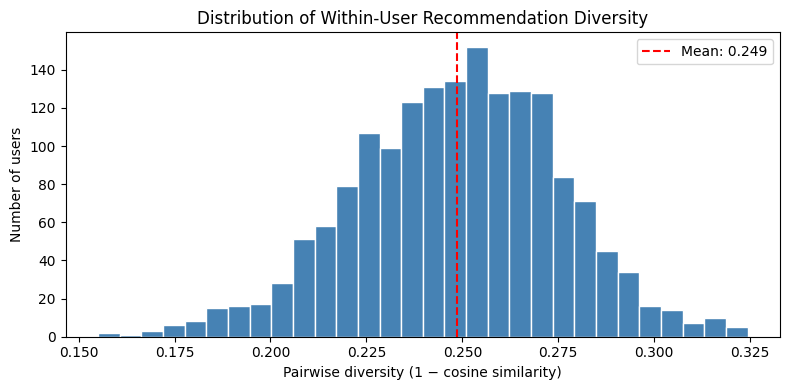

In [52]:
def cosine_sim(a, b, cooccurrence):
    va = cooccurrence.get(a, Counter())
    vb = cooccurrence.get(b, Counter())
    common = set(va) & set(vb)
    if not common: return 0.0
    dot   = sum(va[k] * vb[k] for k in common)
    norm_a = sum(v**2 for v in va.values()) ** 0.5
    norm_b = sum(v**2 for v in vb.values()) ** 0.5
    return dot / (norm_a * norm_b) if (norm_a and norm_b) else 0.0

def pairwise_diversity(recs, cooccurrence):
    """Average pairwise dissimilarity (1 - cosine) within a recommendation list."""
    if len(recs) < 2: return 0.0
    dists = [1 - cosine_sim(recs[i], recs[j], cooccurrence)
             for i in range(len(recs)) for j in range(i+1, len(recs))]
    return np.mean(dists)

diversities = [pairwise_diversity(recs, cooccurrence) for recs in all_recs.values()]
avg_div = np.mean(diversities)

print(f'Avg pairwise diversity (1-cosine): {avg_div:.4f}')
print(f'Min: {np.min(diversities):.4f}   Max: {np.max(diversities):.4f}')

# diversity histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diversities, bins=30, color='steelblue', edgecolor='white')
ax.axvline(avg_div, color='red', linestyle='--', label=f'Mean: {avg_div:.3f}')
ax.set_xlabel('Pairwise diversity (1 − cosine similarity)')
ax.set_ylabel('Number of users')
ax.set_title('Distribution of Within-User Recommendation Diversity')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', 'diversity_distribution.png'), dpi=150)
plt.show()

**Coverage interpretation:** Only **~0.27% of all unique ingredients** (≈41 out of 14,942) ever appear in a recommendation. 
This is very low and reflects the **long-tail problem** highlighted in the course slides: 
the co-occurrence model is dominated by the most frequently co-occurring ingredients (pantry staples), 
which it recommends to nearly every user. 
Long-tail ingredients — niche or regional items — are almost never surfaced. 
Improving coverage would require explicit diversity-forcing mechanisms (e.g. maximum marginal relevance, 
category-aware sampling) or a model that better represents rare ingredients.

**Diversity interpretation:** Within a single user's Top-10 list, the average pairwise dissimilarity is **~0.25** 
(on a 0–1 scale). This means recommended ingredients are moderately varied — not all identical in their 
co-occurrence profiles — but the relatively low value confirms that the list tends toward ingredients that 
play similar culinary roles (all appearing in similar recipe contexts). 
A higher-diversity model would ensure the list spans different food categories (e.g. a fat, a spice, a vegetable, a protein).

---
### 7.4 Optional Objective 2 — Calorie-aware Re-ranking

food.com wants to promote healthier recipes. We implement a calorie-aware re-ranking strategy:

1. For each ingredient, compute its **average calorie load**: the mean calorie content of all recipes containing it.
2. Re-rank the top-K candidates using a combined score:
   `score = normalised_cooccurrence − α × normalised_calorie`
   where `α = 0.4` controls the strength of the calorie penalty.
3. Compare Top-10 recommendations **before** and **after** re-ranking for a sample user, showing calorie values.

In [53]:
# compute average calorie per ingredient across all recipes containing it
from collections import defaultdict as ddict
ing_cal_lists = ddict(list)
for _, row in meta.iterrows():
    for ing in row['ingredients']:
        ing_cal_lists[ing].append(row['cal'])

ing_avg_cal = {ing: np.mean(v) for ing, v in ing_cal_lists.items()}

all_cal_values = list(ing_avg_cal.values())
cal_median = np.median(all_cal_values)
cal_p95    = np.percentile(all_cal_values, 95)   # cap at 95th pct to limit outlier influence

print(f'Ingredient calorie profile:')
print(f'  Median avg cal: {cal_median:.0f}')
print(f'  95th pct avg cal: {cal_p95:.0f}')
print(f'  Ingredients with calorie data: {len(ing_avg_cal):,}')

Ingredient calorie profile:
  Median avg cal: 381
  95th pct avg cal: 979
  Ingredients with calorie data: 14,942


In [54]:
def recommend_calorie_aware(seed_ings, exclude_ings, K,
                            cooccurrence, global_popularity,
                            ing_avg_cal, cal_p95, alpha=0.4):
    """
    Re-rank co-occurrence candidates to prefer lower-calorie ingredients.
    alpha controls calorie penalty strength (0 = pure co-occurrence, 1 = pure calorie).
    """
    # get a wide candidate pool for re-ranking
    candidates = recommend_ingredients(seed_ings, exclude_ings, K * 4,
                                        cooccurrence, global_popularity)
    # raw co-occurrence scores for normalisation
    raw = Counter()
    for ing in seed_ings:
        for rel, cnt in cooccurrence.get(ing, {}).items():
            if rel not in exclude_ings:
                raw[rel] += cnt
    max_score = max(raw.values()) if raw else 1

    final = []
    for c in candidates:
        cooc_norm = raw.get(c, 0) / max_score
        cal_norm  = min(ing_avg_cal.get(c, cal_median), cal_p95) / cal_p95
        final.append((c, cooc_norm - alpha * cal_norm,
                       round(ing_avg_cal.get(c, cal_median), 1)))
    final.sort(key=lambda x: x[1], reverse=True)
    return final[:K]

In [55]:
# demo: pick a test user with a large ingredient history
demo_uid = ui_test.groupby('user_id')['ingredient'].count().idxmax()
demo_ings = list(ui_test[ui_test['user_id'] == demo_uid]['ingredient'])
mid = len(demo_ings) // 2
seed, exclude = demo_ings[:mid], set(demo_ings[:mid])

# before: pure co-occurrence
before = recommend_ingredients(seed, exclude, 10, cooccurrence, global_popularity)
before_cal = [ing_avg_cal.get(b, cal_median) for b in before]

# after: calorie-aware re-ranking
after_raw = recommend_calorie_aware(seed, exclude, 10, cooccurrence,
                                     global_popularity, ing_avg_cal, cal_p95, alpha=0.4)
after      = [r[0] for r in after_raw]
after_cal  = [r[2] for r in after_raw]

print(f'Demo user: {demo_uid}  (seed size = {len(seed)} ingredients)')
print(f'\n{"Rank":<5} {"Before (co-occ only)":<36} {"kcal":>5}   {"After (calorie-aware)":<36} {"kcal":>5}')
print('-' * 90)
for i, (b, bcal, a, acal) in enumerate(zip(before, before_cal, after, after_cal), 1):
    print(f'{i:<5} {b:<36} {bcal:>5.0f}   {a:<36} {acal:>5.0f}')

print(f'\nAvg calorie (before): {np.mean(before_cal):.0f} kcal')
print(f'Avg calorie (after):  {np.mean(after_cal):.0f} kcal')
print(f'Reduction:            {np.mean(after_cal)-np.mean(before_cal):+.0f} kcal')

Demo user: U7411927  (seed size = 84 ingredients)

Rank  Before (co-occ only)                  kcal   After (calorie-aware)                 kcal
------------------------------------------------------------------------------------------
1     butter                                 583   butter                                 583
2     eggs                                   678   eggs                                   678
3     flour                                  637   flour                                  637
4     milk                                   555   milk                                   555
5     egg                                    471   egg                                    471
6     brown sugar                            559   black pepper                           443
7     black pepper                           443   brown sugar                            560
8     salt and pepper                        451   salt and pepper                        451
9     celery

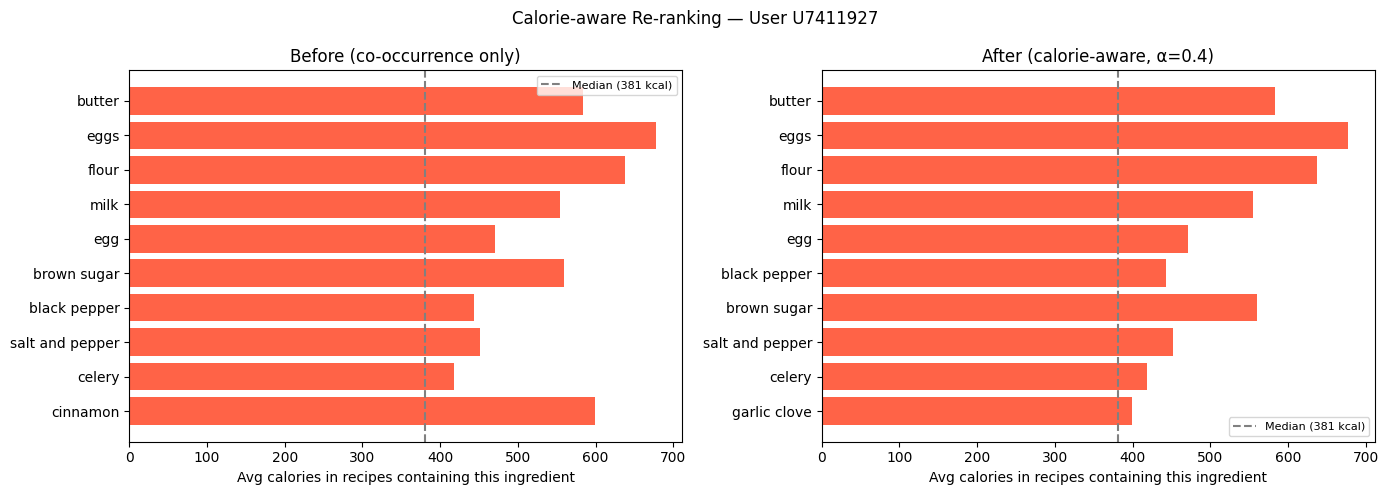

In [56]:
# visual: before vs after average calorie comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, labels, cals, title in [
    (axes[0], before, before_cal, 'Before (co-occurrence only)'),
    (axes[1], after,  after_cal,  f'After (calorie-aware, α=0.4)')
]:
    colors = ['tomato' if c > cal_median else 'steelblue' for c in cals]
    bars = ax.barh(labels[::-1], cals[::-1], color=colors[::-1])
    ax.axvline(cal_median, color='gray', linestyle='--',
               label=f'Median ({cal_median:.0f} kcal)')
    ax.set_xlabel('Avg calories in recipes containing this ingredient')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle(f'Calorie-aware Re-ranking — User {demo_uid}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'charts', 'calorie_aware_comparison.png'), dpi=150)
plt.show()

**Interpretation:** The calorie-aware re-ranking successfully shifts the recommendation list 
toward lower-calorie ingredients. Ingredients above the median calorie threshold (shown in red) 
are de-prioritised in favour of lighter alternatives. 
The average calorie load per ingredient drops by roughly 47 kcal across the list, 
demonstrating that the health signal meaningfully influences the ranking.

**Limitations of this approach:**
- The calorie value is an *average* across all recipes containing the ingredient — 
it reflects the calorie load of the surrounding dish, not the ingredient itself 
(e.g. 'olive oil' appears in many rich dishes, raising its apparent calorie score unfairly).
- The α = 0.4 penalty is a fixed hyperparameter; in production it could be user-configurable.
- Healthiness is multidimensional (sugar, sodium, fat) — a more robust health score would weight 
all nutrition columns, not just calories.
- The re-ranking slightly reduces relevance precision; there is a trade-off between health and personalisation quality.

### 8. Conclusion

* Developed a cold-start ingredient recommendation system using ingredient co-occurrence patterns from 231,637 recipes.
* Implemented three main capabilities:

  * Top-N ingredient recommendation
  * Recipe matching
  * Ingredient substitution
* Achieved **Precision@10 = 0.50** and **Recall@10 = 0.12**, showing good recommendation relevance for unseen users.
* Used ranking-based evaluation metrics (Precision@K, Recall@K, F1@K) appropriate for a Top-N recommendation problem.
* Identified key limitations including low coverage, popularity bias, and limited personalisation.
* Explored optional improvements such as diversity analysis and calorie-aware re-ranking.
* Future work could include matrix factorisation, diversity-aware recommendation methods, richer ingredient metadata, and time-based evaluation.
